# 02_modelling_2 — OU Model + Kalman Filter

**Input:** `cache/prices.parquet`, `cache/sectors.parquet`, `cache/pairs_screened.parquet` (from `02_modelling_1.ipynb`)

**Output:** `cache/pairs_df.parquet` : consumed by `03_strategy.ipynb`

##  Imports & Load Data

In [18]:
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

print("All imports successful.")

All imports successful.


In [19]:
CACHE_DIR = Path("cache")

prices         = pd.read_parquet(CACHE_DIR / "prices.parquet")
sectors        = pd.read_parquet(CACHE_DIR / "sectors.parquet")["sector"]
pairs_screened = pd.read_parquet(CACHE_DIR / "pairs_screened.parquet")

print(f"prices         : {prices.shape[0]} days x {prices.shape[1]} tickers")
print(f"sectors        : {len(sectors)} tickers across {sectors.nunique()} sectors")
print(f"pairs_screened : {len(pairs_screened)} pairs")
print()
pairs_screened.head()

prices         : 4132 days x 262 tickers
sectors        : 262 tickers across 11 sectors
pairs_screened : 26 pairs



,ticker_1,ticker_2,sector,eg_pvalue,eg_hedge_ratio,eg_passed,joh_trace_stat,joh_crit_95,joh_passed,halflife,same_industry,price_corr
0,CPB,CAG,Consumer Staples,0.013219,1.169929,True,20.449240,15.4943,True,95.124425,True,0.904711
1,AFL,CB,Financials,0.037224,0.376527,True,16.973988,15.4943,True,95.822810,True,0.981385
2,AIZ,ALL,Financials,0.010771,1.127354,True,18.466236,15.4943,True,74.360617,True,0.979125
3,AIZ,CINF,Financials,0.000268,1.456365,True,22.213790,15.4943,True,62.112772,True,0.982464
4,ALL,CB,Financials,0.015470,0.707165,True,23.206555,15.4943,True,65.312232,True,0.986159


In [ ]:
bad_tickers = set(prices.columns[prices.isna().any()])
print(f"Dropping {len(bad_tickers)} tickers with NaN: {bad_tickers}")

prices = prices.drop(columns=bad_tickers)

mask = ~(pairs_screened["ticker_1"].isin(bad_tickers) |
         pairs_screened["ticker_2"].isin(bad_tickers))
pairs_screened = pairs_screened[mask].reset_index(drop=True)

print(f"pairs_screened: {len(pairs_screened)} pairs remaining")


Dropping 3 tickers with NaN: {'CHTR', 'CBOE', 'LYB'}
pairs_screened: 25 pairs remaining


In [ ]:
# first pair as the test pair
row = pairs_screened.iloc[0]
T1_TEST, T2_TEST = row["ticker_1"], row["ticker_2"]
print(f"Test pair: {T1_TEST} / {T2_TEST}  (sector: {row['sector']})  "
      f"half-life: {row['halflife']:.1f}d")

Test pair: CPB / CAG  (sector: Consumer Staples)  half-life: 95.1d


---
## Ornstein-Uhlenbeck Spread Model

Fit OU process parameters via MLE using the exact Gaussian transition density.

Parameters: κ (mean reversion speed), μ (long-run mean), σ (spread volatility)

Half-life = ln(2) / κ

In [5]:
def ou_log_likelihood(params: np.ndarray, spread: np.ndarray, dt: float = 1.0) -> float:
    kappa, mu, sigma = params

    if kappa <= 0 or sigma <= 0:
        return 1e10

    e_kdt     = np.exp(-kappa * dt)
    cond_mean = mu + (spread[:-1] - mu) * e_kdt
    cond_var  = sigma**2 * (1 - e_kdt**2) / (2 * kappa)

    if cond_var <= 0:
        return 1e10

    ll = -0.5 * np.sum(
        np.log(2 * np.pi * cond_var) +
        (spread[1:] - cond_mean)**2 / cond_var
    )
    return -ll


def fit_ou_mle(spread: pd.Series) -> dict:
    s = spread.dropna().values

    lag    = s[:-1]
    delta  = np.diff(s)
    b      = np.polyfit(lag, delta, 1)[0]
    kappa0 = max(-b, 0.01)
    mu0    = s.mean()
    sigma0 = delta.std()

    result = minimize(
        ou_log_likelihood,
        x0     = [kappa0, mu0, sigma0],
        args   = (s,),
        method = "L-BFGS-B",
        bounds = [(1e-4, None), (None, None), (1e-4, None)],
    )

    if result.success:
        kappa, mu, sigma = result.x
        return {
            "kappa"    : kappa,
            "mu"       : mu,
            "sigma"    : sigma,
            "halflife" : np.log(2) / kappa,
            "converged": True,
        }
    return {"kappa": np.nan, "mu": np.nan, "sigma": np.nan,
            "halflife": np.nan, "converged": False}


# Test on T1_TEST / T2_TEST using the screened hedge ratio
spread_test = prices[T1_TEST] - row["eg_hedge_ratio"] * prices[T2_TEST]
ou_params   = fit_ou_mle(spread_test)

print(f"OU parameters for {T1_TEST} / {T2_TEST}:")
print(f"  kappa    : {ou_params['kappa']:.6f}  (mean reversion speed)")
print(f"  mu       : {ou_params['mu']:.4f}    (long-run mean)")
print(f"  sigma    : {ou_params['sigma']:.4f}    (volatility)")
print(f"  Half-life: {ou_params['halflife']:.1f} trading days")
print(f"  Converged: {ou_params['converged']}")

OU parameters for CPB / CAG:
  kappa    : 0.007296  (mean reversion speed)
  mu       : 8.6724    (long-run mean)
  sigma    : 0.4113    (volatility)
  Half-life: 95.0 trading days
  Converged: True


### Fit OU parameters to all surviving pairs

In [6]:
log.info(f"Fitting OU parameters to {len(pairs_screened)} surviving pairs...")

ou_records = []
for _, row in pairs_screened.iterrows():
    t1, t2 = row["ticker_1"], row["ticker_2"]
    s1 = prices[t1]
    s2 = prices[t2]
    common = s1.index.intersection(s2.index)
    spread = s1[common] - row["eg_hedge_ratio"] * s2[common]
    ou = fit_ou_mle(spread)
    ou_records.append(ou)

ou_df = pd.DataFrame(ou_records)

pairs_df = pairs_screened.copy()
pairs_df["ou_kappa"]     = ou_df["kappa"].values
pairs_df["ou_mu"]        = ou_df["mu"].values
pairs_df["ou_sigma"]     = ou_df["sigma"].values
pairs_df["ou_halflife"]  = ou_df["halflife"].values
pairs_df["ou_converged"] = ou_df["converged"].values

n_before = len(pairs_df)
pairs_df = pairs_df[pairs_df["ou_converged"]].reset_index(drop=True)
print(f"MLE converged for {len(pairs_df)}/{n_before} pairs.")
pairs_df.head(10)

13:09:43  INFO      Fitting OU parameters to 25 surviving pairs...


MLE converged for 25/25 pairs.


,ticker_1,ticker_2,sector,eg_pvalue,eg_hedge_ratio,eg_passed,joh_trace_stat,joh_crit_95,joh_passed,halflife,same_industry,price_corr,ou_kappa,ou_mu,ou_sigma,ou_halflife,ou_converged
0,CPB,CAG,Consumer Staples,0.013219,1.169929,True,20.449240,15.4943,True,95.124425,True,0.904711,0.007296,8.672373,0.411324,95.002614,True
1,AFL,CB,Financials,0.037224,0.376527,True,16.973988,15.4943,True,95.822810,True,0.981385,0.007294,-7.785038,0.645633,95.034278,True
2,AIZ,ALL,Financials,0.010771,1.127354,True,18.466236,15.4943,True,74.360617,True,0.979125,0.009310,1.923872,1.663930,74.449044,True
3,AIZ,CINF,Financials,0.000268,1.456365,True,22.213790,15.4943,True,62.112772,True,0.982464,0.011200,-4.537347,1.693096,61.886144,True
4,ALL,CB,Financials,0.015470,0.707165,True,23.206555,15.4943,True,65.312232,True,0.986159,0.010691,-12.181748,1.299475,64.834930,True
5,ALL,CINF,Financials,0.009110,1.328808,True,16.681161,15.4943,True,90.844016,True,0.975547,0.007690,-8.279508,1.482185,90.133431,True
6,AMP,BX,Financials,0.018173,3.143976,True,18.250205,15.4943,True,88.518162,True,0.977645,0.007881,20.899054,4.080800,87.951129,True
7,BLK,SCHW,Financials,0.008585,11.808311,True,23.037524,15.4943,True,91.193793,True,0.963516,0.007631,-49.716204,9.737333,90.832619,True
8,SCHW,CME,Financials,0.017841,0.318383,True,16.754228,15.4943,True,96.486055,True,0.946679,0.007202,4.646985,0.965886,96.247397,True
9,A,DHR,Health Care,0.001390,0.497725,True,20.972568,15.4943,True,61.139317,True,0.987421,0.011677,17.311668,1.143424,59.362115,True


---
## Kalman Filter Dynamic Hedge Ratio

State space: Y_t = X_t·β_t + α_t + ε_t  (observation)

[β_t, α_t] = [β_{t-1}, α_{t-1}] + η_t  (state transition - random walk)

Kalman gain blends the prior estimate with each new observation optimally.

In [7]:
class KalmanFilterHedge:
    def __init__(self, delta: float = 1e-4, R: float = 1e-3):
        self.delta = delta
        self.R     = R
        self.Q     = delta / (1 - delta) * np.eye(2)
        self.state = np.zeros(2)
        self.cov   = np.eye(2) * 1.0

    def update(self, y: float, x: float):
        obs_vec    = np.array([x, 1.0])
        state_pred = self.state
        cov_pred   = self.cov + self.Q

        y_hat = obs_vec @ state_pred
        innov = y - y_hat
        S     = obs_vec @ cov_pred @ obs_vec + self.R
        K     = cov_pred @ obs_vec / S

        self.state = state_pred + K * innov
        self.cov   = (np.eye(2) - np.outer(K, obs_vec)) @ cov_pred

        beta   = self.state[0]
        spread = y - (x * beta + self.state[1])
        return beta, spread, S


def apply_kalman_filter(s1: pd.Series, s2: pd.Series, delta: float = 1e-4) -> pd.DataFrame:
    common = s1.index.intersection(s2.index)
    s1, s2 = s1[common], s2[common]

    # Drop days where either series has NaN (e.g. ticker not yet listed)
    mask = s1.notna() & s2.notna()
    s1, s2 = s1[mask], s2[mask]

    ols_beta   = np.polyfit(s2.values, s1.values, 1)[0]
    spread_ols = s1 - ols_beta * s2

    kf = KalmanFilterHedge(delta=delta, R=spread_ols.var())

    betas          = np.zeros(len(s1))
    spreads_kalman = np.zeros(len(s1))

    for i, (y, x) in enumerate(zip(s1.values, s2.values)):
        beta, spread, _ = kf.update(y, x)
        betas[i]          = beta
        spreads_kalman[i] = spread

    return pd.DataFrame({
        "beta"         : betas,
        "spread_kalman": spreads_kalman,
        "spread_ols"   : spread_ols.values,
    }, index=common)


kf_result = apply_kalman_filter(prices[T1_TEST], prices[T2_TEST])
print(f"Kalman filter applied to {T1_TEST}/{T2_TEST}")
print(f"Beta range     : {kf_result['beta'].min():.3f} -> {kf_result['beta'].max():.3f}")
print(f"Spread (Kalman): mean={kf_result['spread_kalman'].mean():.4f}, "
      f"std={kf_result['spread_kalman'].std():.4f}")
print(f"Spread (OLS)   : mean={kf_result['spread_ols'].mean():.4f}, "
      f"std={kf_result['spread_ols'].std():.4f}")

Kalman filter applied to CPB/CAG
Beta range     : 0.882 -> 2.136
Spread (Kalman): mean=-0.0265, std=1.0699
Spread (OLS)   : mean=8.6697, std=3.3893


### OLS vs Kalman hedge ratio and spread

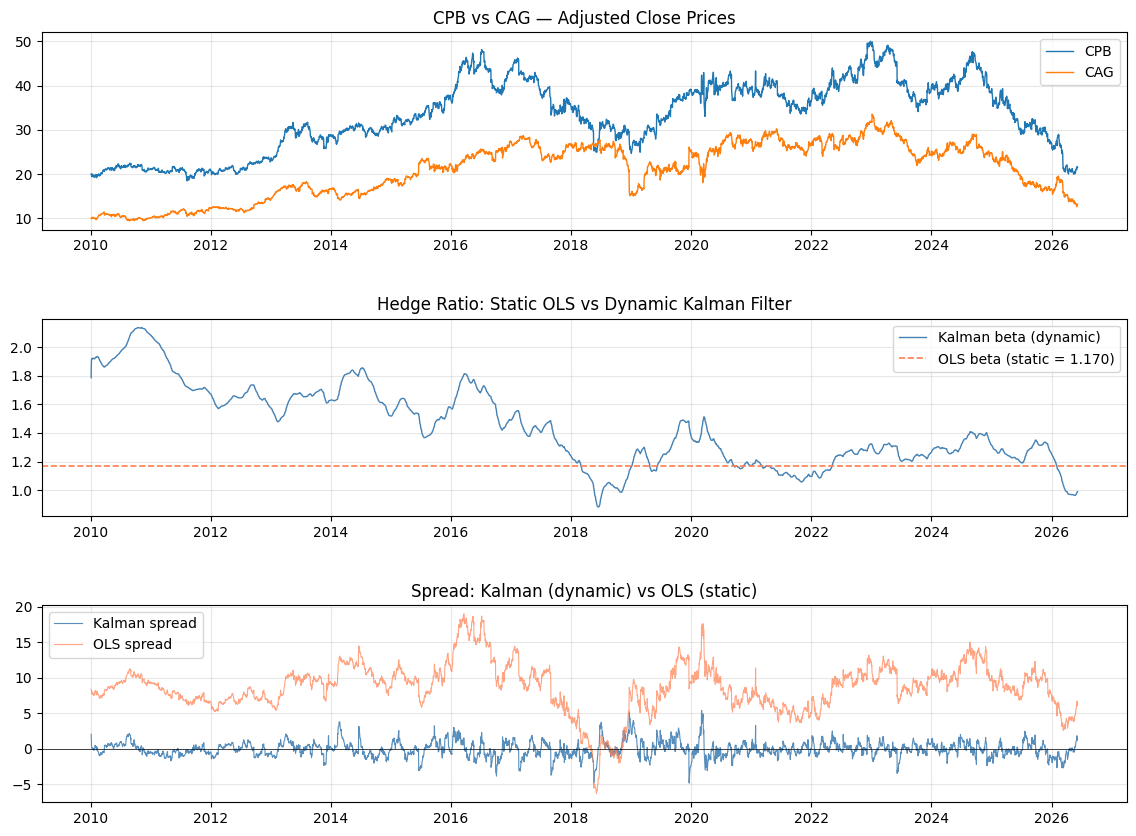

In [8]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 1, hspace=0.45)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

ax1.plot(prices[T1_TEST], label=T1_TEST, linewidth=1.0)
ax1.plot(prices[T2_TEST], label=T2_TEST, linewidth=1.0)
ax1.set_title(f"{T1_TEST} vs {T2_TEST} — Adjusted Close Prices")
ax1.legend()
ax1.grid(True, alpha=0.3)

ols_beta_full = np.polyfit(
    prices[T2_TEST].dropna().values, prices[T1_TEST].dropna().values, 1)[0]
ax2.plot(kf_result.index, kf_result["beta"],
         label="Kalman beta (dynamic)", linewidth=1.0, color="steelblue")
ax2.axhline(ols_beta_full, color="coral", linestyle="--", linewidth=1.2,
            label=f"OLS beta (static = {ols_beta_full:.3f})")
ax2.set_title("Hedge Ratio: Static OLS vs Dynamic Kalman Filter")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.plot(kf_result.index, kf_result["spread_kalman"],
         label="Kalman spread", linewidth=0.8, color="steelblue", alpha=0.9)
ax3.plot(kf_result.index, kf_result["spread_ols"],
         label="OLS spread", linewidth=0.8, color="coral", alpha=0.7)
ax3.axhline(0, color="black", linestyle="-", linewidth=0.5)
ax3.set_title("Spread: Kalman (dynamic) vs OLS (static)")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.savefig(CACHE_DIR / "kalman_vs_ols.png", dpi=130, bbox_inches="tight")
plt.show()

### Stationarity comparison: does Kalman spread beat OLS?

In [9]:
def adf_summary(series: pd.Series, label: str) -> dict:
    result = adfuller(series.dropna(), autolag="AIC")
    adf_stat, pvalue = result[0], result[1]
    status = "stationary" if pvalue < 0.05 else "NOT stationary"
    print(f"{label:30s}  ADF: {adf_stat:8.4f}  p={pvalue:.6f}  {status}")
    return {"adf_stat": adf_stat, "pvalue": pvalue}


print(f"ADF Stationarity — {T1_TEST}/{T2_TEST}")
print("-" * 70)
adf_ols    = adf_summary(kf_result["spread_ols"],    "OLS spread (static)")
adf_kalman = adf_summary(kf_result["spread_kalman"], "Kalman spread (dynamic)")
print()
print(f"Improvement: {adf_ols['adf_stat'] - adf_kalman['adf_stat']:.4f} "
      "(Kalman more negative = better stationarity)")

ADF Stationarity — CPB/CAG
----------------------------------------------------------------------
OLS spread (static)             ADF:  -3.7974  p=0.002934  stationary
Kalman spread (dynamic)         ADF: -11.7764  p=0.000000  stationary

Improvement: 7.9790 (Kalman more negative = better stationarity)


### Apply Kalman filter to all surviving pairs

In [10]:
log.info(f"Applying Kalman filter to {len(pairs_df)} surviving pairs...")

kalman_betas = []
kalman_adf   = []
ols_adf      = []

for _, row in pairs_df.iterrows():
    t1, t2 = row["ticker_1"], row["ticker_2"]
    kf_res = apply_kalman_filter(prices[t1], prices[t2])

    kalman_betas.append(kf_res["beta"].iloc[-1])

    adf_k = adfuller(kf_res["spread_kalman"].dropna(), autolag="AIC")
    adf_o = adfuller(kf_res["spread_ols"].dropna(),    autolag="AIC")
    kalman_adf.append(adf_k[1])
    ols_adf.append(adf_o[1])

pairs_df["kalman_beta_final"] = kalman_betas
pairs_df["kalman_adf_pval"]   = kalman_adf
pairs_df["ols_adf_pval"]      = ols_adf

n_kalman_better = (pairs_df["kalman_adf_pval"] < pairs_df["ols_adf_pval"]).sum()
print(f"Kalman spread more stationary: {n_kalman_better}/{len(pairs_df)} pairs "
      f"({n_kalman_better/len(pairs_df)*100:.1f}%)")
print(f"  Median OLS p-value    : {pairs_df['ols_adf_pval'].median():.6f}")
print(f"  Median Kalman p-value : {pairs_df['kalman_adf_pval'].median():.6f}")

13:19:12  INFO      Applying Kalman filter to 25 surviving pairs...


Kalman spread more stationary: 25/25 pairs (100.0%)
  Median OLS p-value    : 0.002586
  Median Kalman p-value : 0.000000


In [11]:
print(pairs_df[["ticker_1", "ticker_2", "sector", "halflife"]
      ].sort_values("sector").to_string())


   ticker_1 ticker_2                  sector   halflife
0       CPB      CAG        Consumer Staples  95.124425
1       AFL       CB              Financials  95.822810
2       AIZ      ALL              Financials  74.360617
3       AIZ     CINF              Financials  62.112772
4       ALL       CB              Financials  65.312232
5       ALL     CINF              Financials  90.844016
6       AMP       BX              Financials  88.518162
7       BLK     SCHW              Financials  91.193793
8      SCHW      CME              Financials  96.486055
9         A      DHR             Health Care  61.139317
10      BDX      COO             Health Care  84.824357
11      CNC      HUM             Health Care  92.928302
12      CRL     TECH             Health Care  50.355740
13      AME      EMR             Industrials  73.240773
14      CAT      CMI             Industrials  86.859720
15      EMR      ETN             Industrials  85.238997
16     AMAT      AMD  Information Technology  82

---
## Save Output for Strategy Notebook

In [12]:
pairs_df.to_parquet(CACHE_DIR / "pairs_df.parquet", index=False)
print(f"Saved pairs_df with {len(pairs_df)} pairs to cache/pairs_df.parquet")
print()
print("Columns:")
for col in pairs_df.columns:
    print(f"  {col:25s}  {pairs_df[col].dtype}")

Saved pairs_df with 25 pairs to cache/pairs_df.parquet

Columns:
  ticker_1                   str
  ticker_2                   str
  sector                     str
  eg_pvalue                  float64
  eg_hedge_ratio             float64
  eg_passed                  bool
  joh_trace_stat             float64
  joh_crit_95                float64
  joh_passed                 bool
  halflife                   float64
  same_industry              bool
  price_corr                 float64
  ou_kappa                   float64
  ou_mu                      float64
  ou_sigma                   float64
  ou_halflife                float64
  ou_converged               bool
  kalman_beta_final          float64
  kalman_adf_pval            float64
  ols_adf_pval               float64
